In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

import pandas as pd
import os

plt.rcParams['axes.labelsize'] = 20


0.6777 74.71913613009617 74.71913613009617


In [2]:

def load_pairwise_galaxy_cat(file_path):
    """
    Loads binned HDF5 galaxy catalog data saved by bin_pairwise_galaxy_cat.
    
    Parameters:
    - file_path: str, the exact path to the saved .h5 file
    
    Returns:
    - binned_dict: The reconstructed nested dictionary dict[k][R_bin_idx][rlos_bin_idx]
    - master_df: The full loaded Pandas DataFrame
    """
    # 1. Load the master DataFrame using the key we defined during saving
    master_df = pd.read_hdf(file_path, key='binned_data')
    
    # 2. Reconstruct the nested dictionary using the exact same groupby logic
    binned_dict = {}
    
    for (k, r_i, rlos_i), group in master_df.groupby(['Mvir_bin', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
            'Mvir': group['Mvir'].values
        }
        
    return binned_dict, master_df

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

# Load data
data_dict, df = load_pairwise_galaxy_cat('/spiff/cosweeney/simulations/MDPL2/data/binned_data/binned_M10_8.00e+13-8.00e+14_R25_5.0-30.0_rlos120_-60.0-60.0.h5')

In [3]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins, just out to 30/69 for now
R_edges = np.linspace(5, 30, (30-5)+1)
R_cens = (R_edges[1:]+R_edges[:-1])/2.0 

rlos_edges = np.linspace(0, 60, (60-0)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0 

rlos_edges_dual = np.linspace(-60, 60, (60-(-60))+1)
rlos_cens_dual = (rlos_edges_dual[1:]+rlos_edges_dual[:-1])/2.0 

# update Mass bins
Mvir = np.array(df['Mvir']) # Host halo virial mass

mbins2 = np.logspace(np.log10(8e13), np.log10(8e14), 10+1)

Mvirs2=[]
for i in range(len(mbins2)-1):
    mmask = (Mvir>=mbins2[i])&(Mvir<=mbins2[i+1])
    Ms = Mvir[mmask] 

    Mvirs2.append(np.median(Ms))
Mvirs2=np.array(Mvirs2)


massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [4]:
# reconstruct vr_peak interpolator
save_path = '/spiff/cosweeney/simulations/MDPL2/data/models'

data = np.load(save_path+'vr_peak_r_RBS_data.npz')
from scipy.interpolate import RectBivariateSpline

# Re-initialize the object (we use a dummy grid then overwrite)
RBinterp = RectBivariateSpline.__new__(RectBivariateSpline)
RBinterp.tck = (data['tx'], data['ty'], data['c'])
RBinterp.degrees = (data['kx'], data['ky'])


# reconstruct ST \xi parameter interpolator
from scipy.interpolate import RegularGridInterpolator

save_path = '/spiff/cosweeney/simulations/MDPL2/data/models'


data = np.load(save_path+'xi_from_peak_rgi_data.npz')
xi_int = RegularGridInterpolator(
    (data['points_0'], data['points_1'], data['points_2']), 
    data['values'], 
    method=str(data['method']), 
    bounds_error=False, 
    fill_value=None
)

from scipy.optimize import fsolve

def solve_ST_peak(stpars, init_guess):
    xi, omega, alpha, nu = stpars

    def tau(x):
        return np.sqrt((nu+1)/(nu+x**2))

    def f(z):
        return z - ( (alpha * nu)/(nu + 1) ) * tau(z) * t.pdf(alpha*z*tau(z), df=nu+1) / t.cdf(alpha*z*tau(z), df=nu+1)
    
    soln = fsolve(f, x0=(init_guess-xi)/omega, full_output=True, xtol=1e-18 )

    return xi + omega * soln[0]

def xi_from_peak(mode, omega, alpha, nu):
    """
    Given a known mode and shape parameters, return xi such that
    the skew-t distribution with (xi, omega, alpha, nu) has its peak
    at `mode`.
    """
    # Solve for z* using xi=0 as placeholder — xi cancels out of f(z)
    z_star = solve_ST_peak(stpars=(0.0, omega, alpha, nu), init_guess=1)  # returns xi + omega*z*, with xi=0
    # z_star here is actually omega*z* (since xi=0, the return is 0 + omega*z_star)
    
    # So: xi = mode - omega*z_star (where omega*z_star is what solve_ST_peak returned)
    return mode - z_star

In [5]:
# Plot measured dispersions, compare to \sigma_v resulting from latest fits

meas_sigv = np.zeros((len(Mvirs2), len(R_cens), len(rlos_cens)))

for k in range(len(Mvirs2)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens)):
            #mask = (restored_df['R'] > R_edges[j])&(restored_df['R'] > R_edges[j])&(restored_df['rlos'] > rlos_edges[i])&(restored_df['rlos'] < rlos_edges[i+1])&(restored_df['Mvir'] > mbins2[k])&(restored_df['Mvir'] < mbins2[k+1])
            std = np.std(data_dict[k][j][i+59]['vpeclos'])
            meas_sigv[k, j, i] = std

In [6]:
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'


sigma_h_vlos = np.zeros(len(Mvirs2))

with h5.File(halo_path, 'r') as hcat:

    for k, M in enumerate(Mvirs2):
        hm_cut = (hcat['mvir'][()] >= mbins2[k])&(hcat['mvir'][()] <= mbins2[k+1])

        #print(np.sum(hm_cut))

        hvel = np.array([
            hcat['vx'][()][hm_cut],
            hcat['vy'][()][hm_cut], 
            hcat['vz'][()][hm_cut],
        ]).T

        sigma_h_vlos[k] = np.std(hvel[:, 2])

gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'

box_length = 1000 #Mpc/h, MDPL2 box side length

sigma_g_vlos = np.zeros(len(Mvirs2))

with h5.File(gal_path, 'r') as gcat:
    for k in range(len(Mvirs2)):
        #print(gcat.keys())
        sm_cut = gcat['sm'][()] > 1e10
        m_cut = (gcat['m'][()] >= mbins2[k])&(gcat['m'][()] < mbins2[k+1])

        mask = sm_cut & m_cut

        gvel = np.array([
            gcat['pos'][:, 3][()][mask],
            gcat['pos'][:, 4][()][mask], 
            gcat['pos'][:, 5][()][mask],
        ]).T

        sigma_g_vlos[k] = np.std(gvel[:, 2])

In [7]:
from colossus.lss import bias

def col_xihm(r, M):
    b_h = bias.haloBias(M, redshift, mdef='vir', model='comparat17')

    xi = cosmo.correlationFunction(r, redshift, ps_args={'model':'camb'})

    return b_h * xi

Determine $\sigma_v^2(r(1-\cos\theta))$, and necessary $\rho$. 

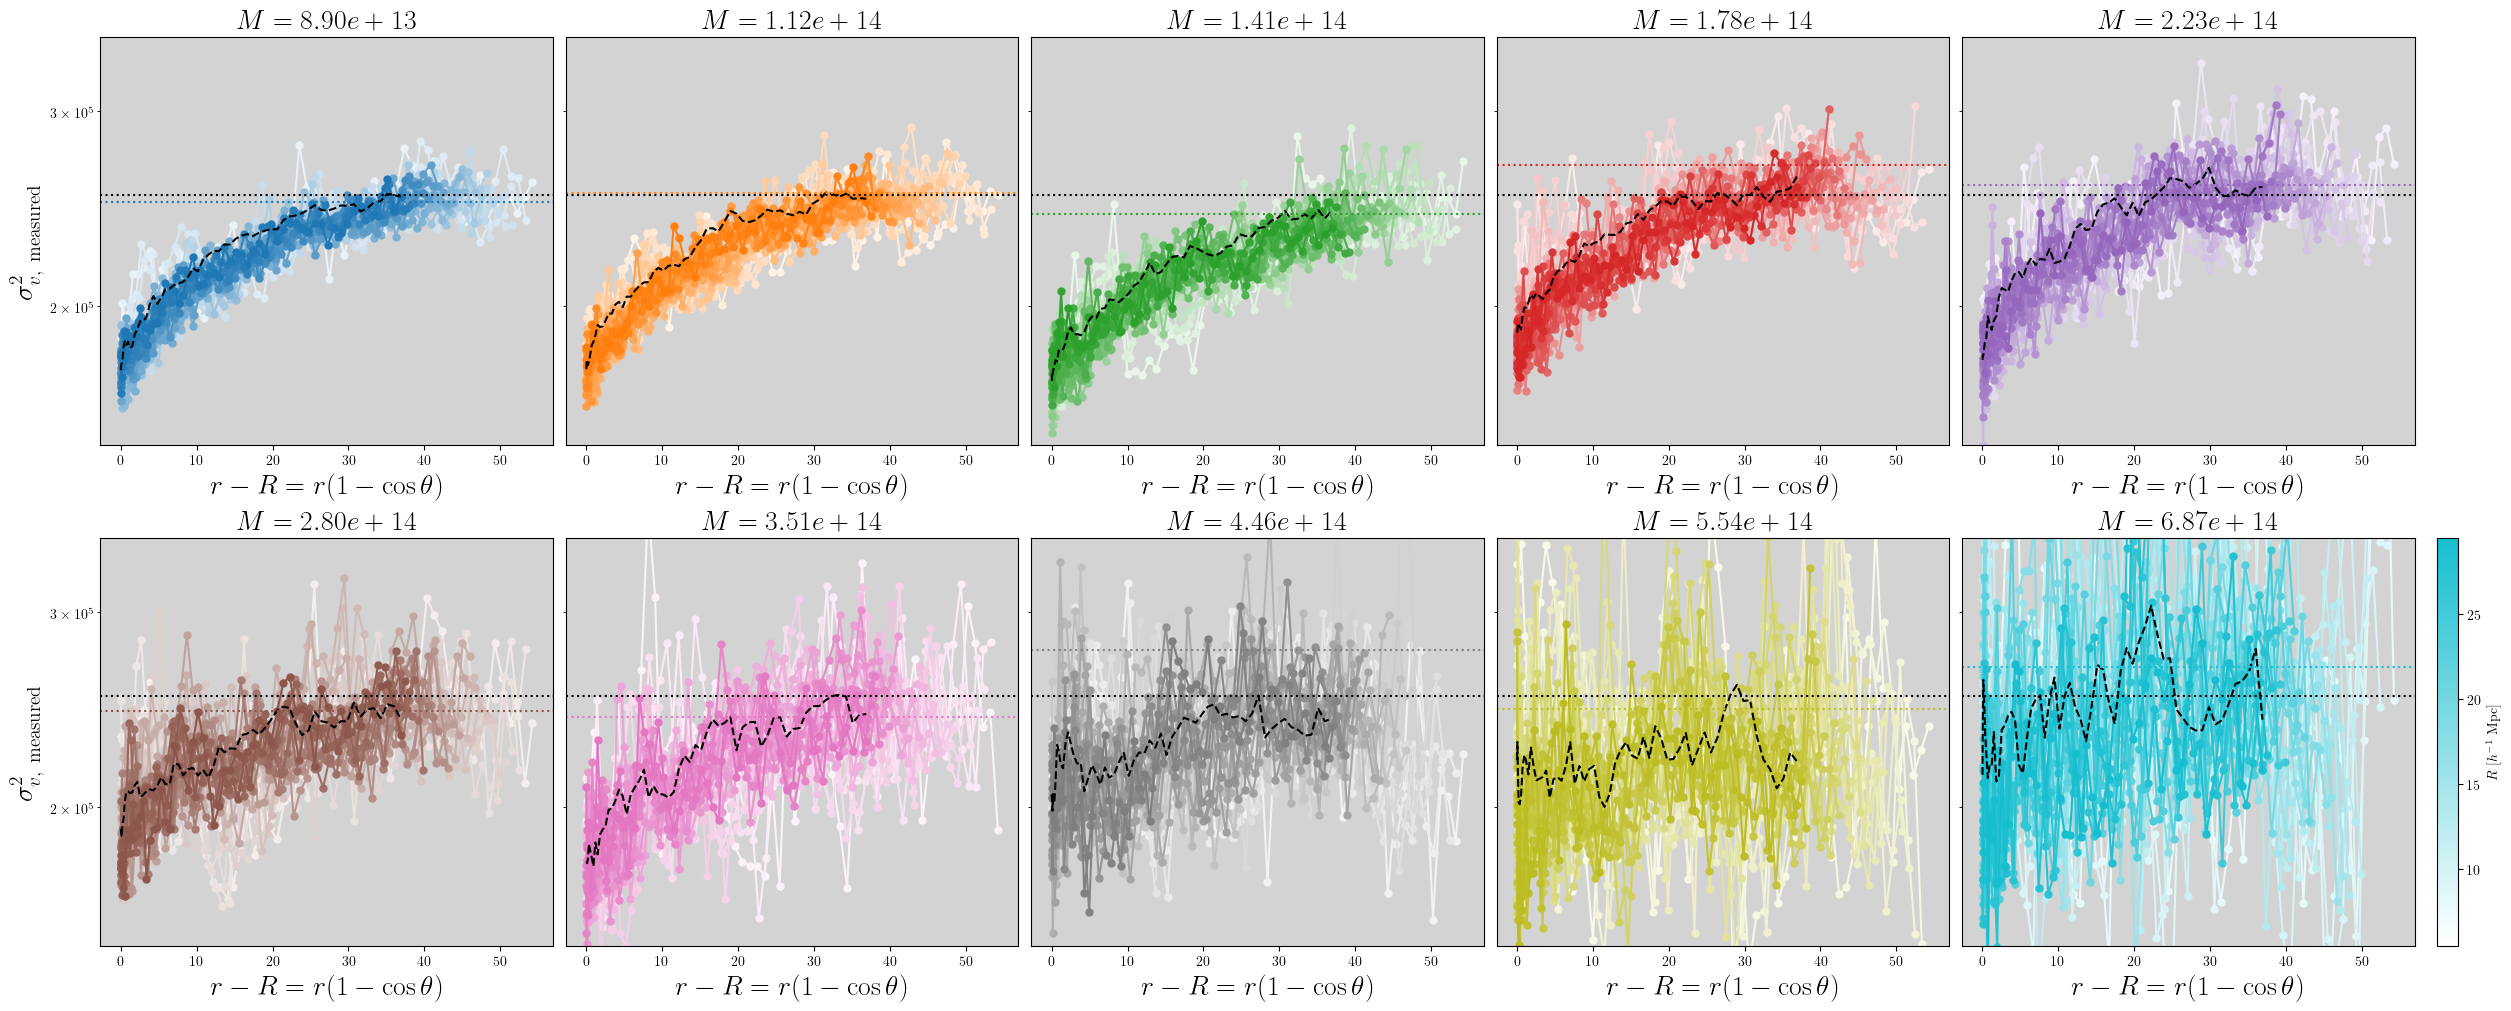

In [7]:
import math
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ncols = math.ceil(len(Mvirs2) / 2)   # row 1 length; row 2 = len(Mvirs2)//2
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=True)
ax = axes.flatten()                    # index linearly: ax[k] as before

ys     = meas_sigv**2
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

rho_x_M = np.zeros((len(Mvirs2), nR, nlos))

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)
        ax[k].plot(r - R, ys[k, j], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R = r(1-\cos\theta)$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        ax[k].set_yscale('log')
        ax[k].set_ylim((1.5e5, 3.5e5))
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)

        rho_x_M[k, j] = 1 - ys[k, j]/(2*(355)**2)
    
    ax[k].plot(r - R, np.mean(ys[k], axis=0), c='k', ls='--')
    ax[k].axhline(2*(355)**2, c='k', ls=':')
    ax[k].axhline(2*sigma_h_vlos[k]**2, c=f'C{k}', ls=':')

# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\sigma_{v, \ \rm measured}^2$', fontsize=20)
axes[1, 0].set_ylabel(r'$\sigma_{v, \ \rm measured}^2$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

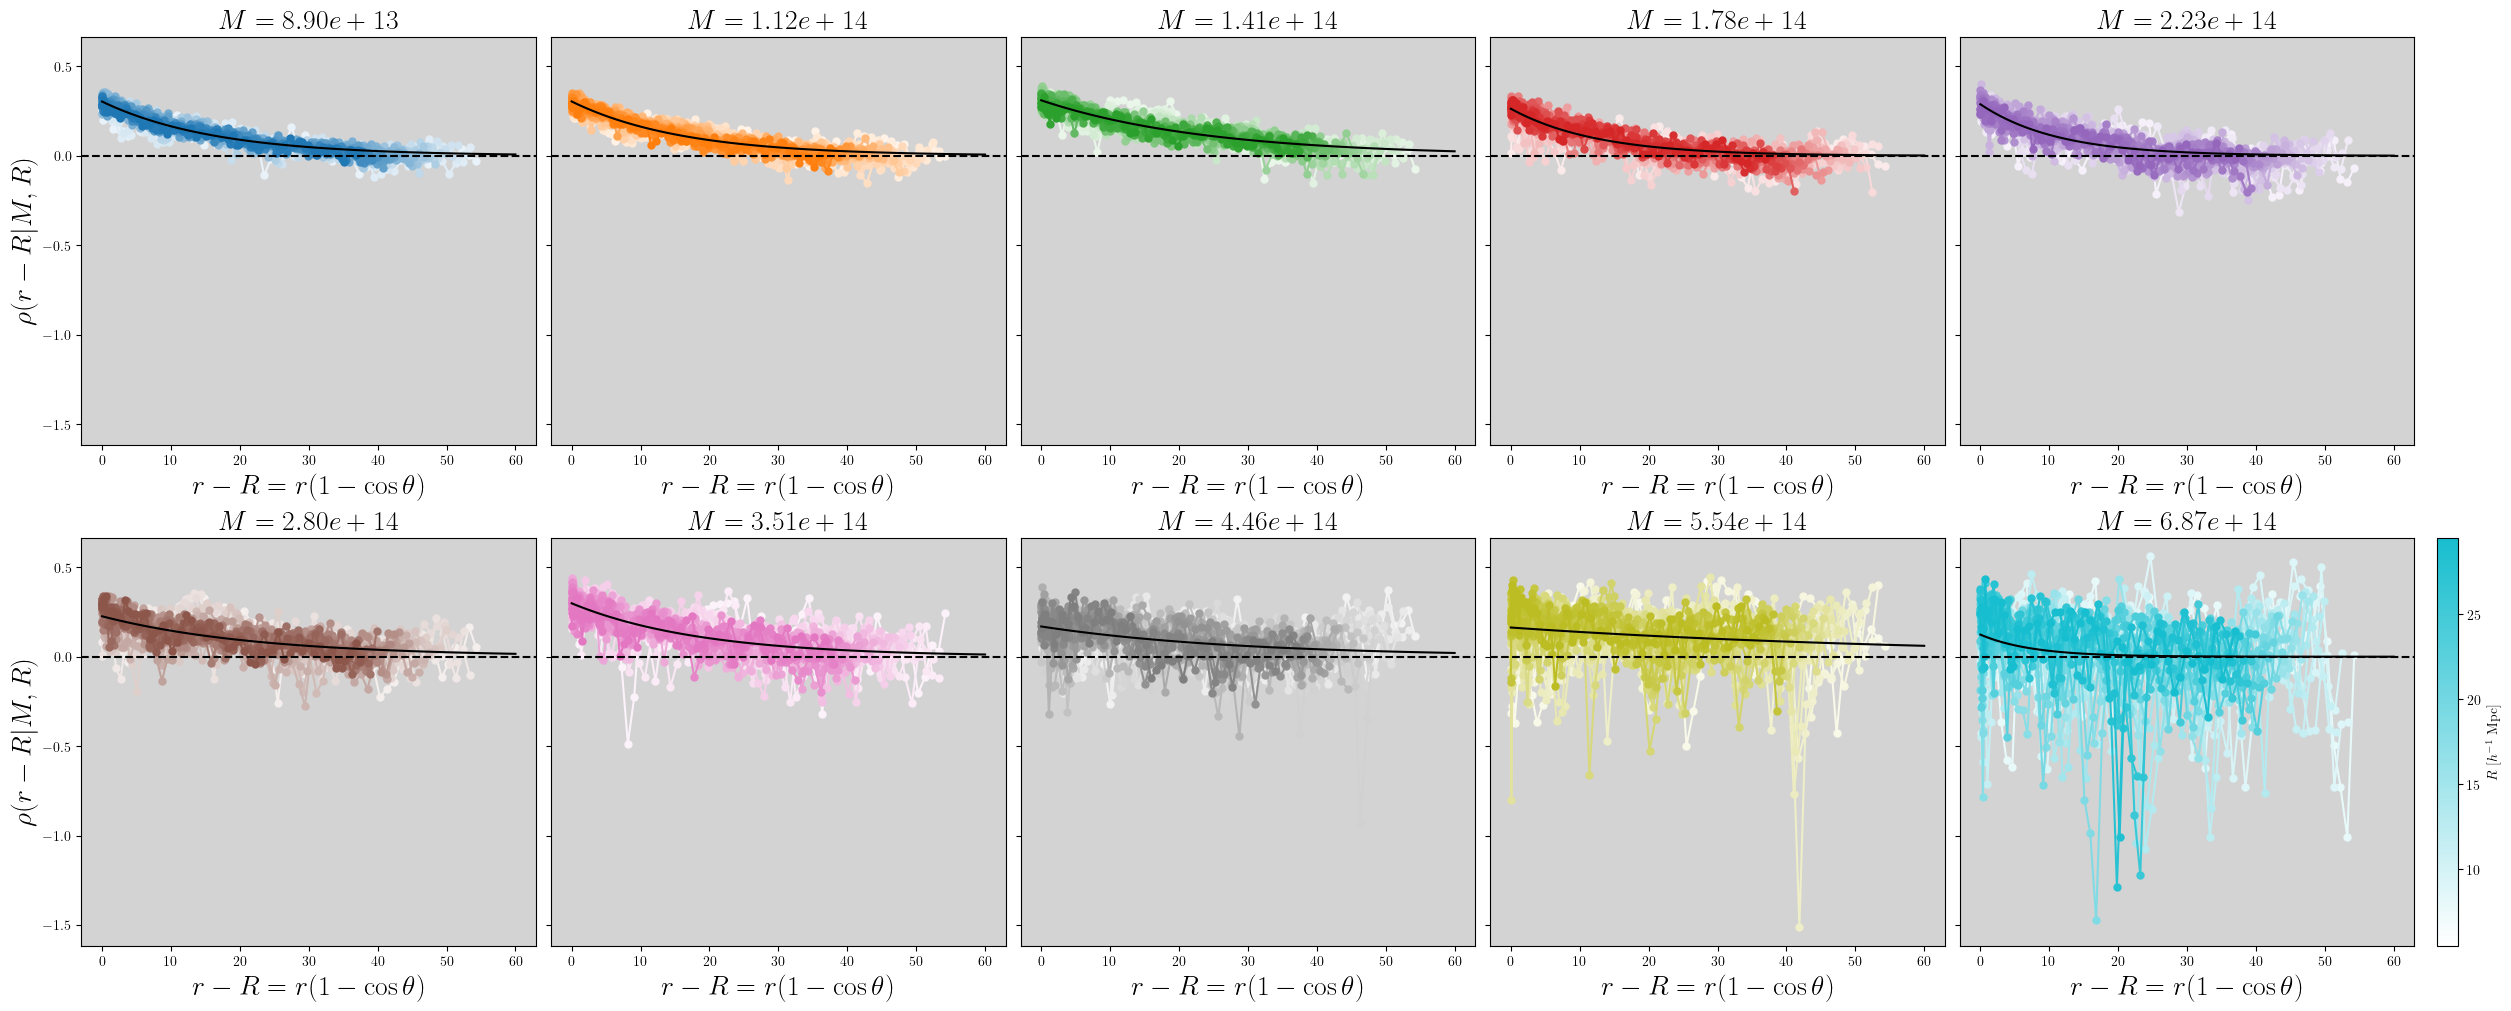

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=True)
ax = axes.flatten()                    # index linearly: ax[k] as before

ys     = meas_sigv**2
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

r_grid = np.sqrt(R_cens[:, None]**2 + rlos_cens[None, :]**2)
x_grid = r_grid - R_cens[:, None]

xs = np.linspace(0, 60, 100)

sig_rho = np.zeros((len(Mvirs2), 2))

a_rho = np.zeros(len(Mvirs2))

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)
        ax[k].plot(r - R, rho_x_M[k, j], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R = r(1-\cos\theta)$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        #ax[k].set_yscale('log')
        #ax[k].set_ylim((1.5e5, 3.5e5))
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)

    ax[k].axhline(0, c='k', ls='--')

    exp_fcn = lambda x, a, s: a*np.exp(-x/s)
    p, c = curve_fit(exp_fcn, x_grid.flatten(), rho_x_M[k].flatten(), p0=[2, 10], maxfev=10_000)
    sig_rho[k] = p
    ax[k].plot(xs, exp_fcn(xs, *p), c='k', ls='-')


    p, c = curve_fit(lambda x, a: exp_fcn(x, a, sig_rho[0, 1]), x_grid.flatten(), rho_x_M[k].flatten(), p0=[2], maxfev=10_000)
    a_rho[k] = p
    #ax[k].plot(xs, exp_fcn(xs, a_rho[k], sig_rho[0, 1]), c='k', ls=':')

    #ax[k].plot(xs, exp_fcn(xs, line(Mvirs2[k]/1e14, *ap_pars), sig_rho[0, 1]), c='k', ls=':')

    #ax[k].plot(xs, exp_fcn(xs, plaw(Mvirs2[k]/1e14, *ap_pars), np.mean(sig_rho[:-3, 1])), c='k', ls=':')

# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\rho(r-R|M, R)$', fontsize=20)
axes[1, 0].set_ylabel(r'$\rho(r-R|M, R)$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

16.468923166973276


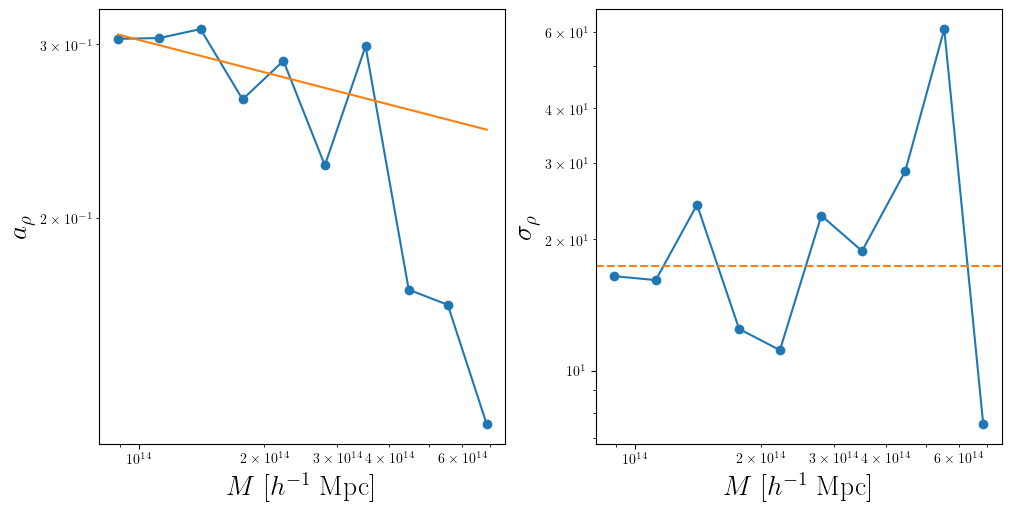

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

names = [r'$a_\rho$', r'$\sigma_\rho$']

for i in range(2):
    ax[i].loglog(Mvirs2, sig_rho[:, i], marker='o')
    ax[i].set_xlabel(r"$M \ [h^{-1}$ Mpc]", fontsize=20)
    ax[i].set_ylabel(names[i], fontsize=20)

ms = np.linspace(Mvirs2[0], Mvirs2[-1], 100)
ap_pars, c = curve_fit(plaw, Mvirs2[:-3]/1e14, sig_rho[:-3, 0])
ax[0].plot(ms, plaw(ms/1e14, *ap_pars), c='C1')

ax[1].axhline(np.mean(sig_rho[:-3, 1]), c='C1', ls='--')

print(sig_rho[0, 1])

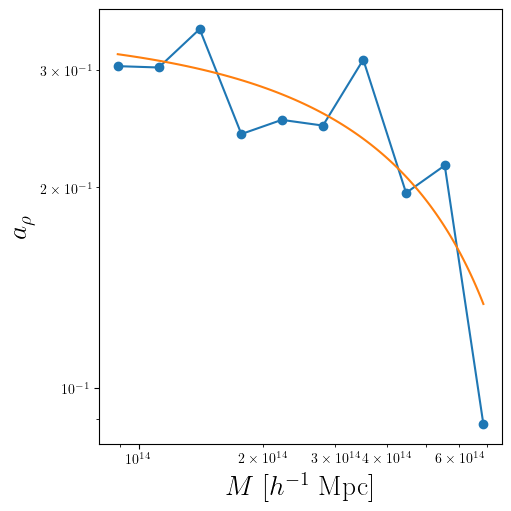

In [10]:
fig, ax = plt.subplots( figsize=(5, 5), layout='constrained')

ax.loglog(Mvirs2, a_rho, marker='o')
ax.set_xlabel(r"$M \ [h^{-1}$ Mpc]", fontsize=20)
ax.set_ylabel(r'$a_\rho$', fontsize=20)

ms = np.linspace(Mvirs2[0], Mvirs2[-1], 100)
ap_pars, c = curve_fit(line, Mvirs2/1e14, a_rho)
ax.plot(ms, line(ms/1e14, *ap_pars), c='C1')

In [8]:

rho_pars = np.array([-0.03055477,  0.34374933, 16.46892317])#np.array([ap_pars[0], ap_pars[1], sig_rho[0, 1]])
print(rho_pars)

def rho_mod(x, M, pars):
    am, ab, s = pars
    a = line(M/1e14, am, ab)
    return a*np.exp(-x/s)

def sig_vm(x, M, pars):
    rho = rho_mod(x, M, pars)
    s_0 = 355

    return np.sqrt(2*s_0**2 * (1 - rho))

[-0.03055477  0.34374933 16.46892317]


In [9]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf

In [12]:
STpars = np.zeros((len(Mvirs2), len(R_cens), len(rlos_cens), 3))
STerrs = np.zeros(STpars.shape)

for k in range(len(Mvirs2)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens)):
            try:

                r = np.sqrt(R_cens[j]**2 + rlos_cens[i]**2)
                theta = np.arctan2(rlos_cens[i], R_cens[j])
                sin = np.sin(theta)

                peak = RBinterp(np.log10(Mvirs2[k]), r).squeeze()*sin 

                ve = np.linspace(peak-2500, peak+2500, 50+1)
                vc = 0.5*(ve[1:] + ve[:-1])

                hist, edges = np.histogram(data_dict[k][j][i+59]['vpeclos'], bins='auto', range=[peak-2500, peak+2500], density=True)
                cent = 0.5*(edges[1:] + edges[:-1])

                if np.isnan(hist).any():
                    break
                else:
                    p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi, omega, alpha, nu=6), cent, hist, p0=[peak, 400, -0.1], maxfev=5_000)
                    
                    STpars[k, j, i] = p
                    STerrs[k, j, i] = np.sqrt(np.diag(c))

            except RuntimeError as e:
                # Fit failed to converge - skip this bin
                print(f"Fit failed for bin (k={k}, j={j}, i={i}): {e}")
                continue
            except Exception as e:
                # Catch any other errors
                print(f"Unexpected error for bin (k={k}, j={j}, i={i}): {e}")
                continue

In [13]:
# save data
save_path = '/spiff/cosweeney/simulations/MDPL2/data/'

np.save(save_path+'M10_R_rlos_30_60_STpars', STpars)

np.save(save_path+'M10_R_rlos_30_60_STerrs', STerrs)

In [10]:
# load data
save_path = '/spiff/cosweeney/simulations/MDPL2/data/'

STpars = np.load(save_path+'M10_R_rlos_30_60_STpars.npy')

STerrs = np.load(save_path+'M10_R_rlos_30_60_STerrs.npy')

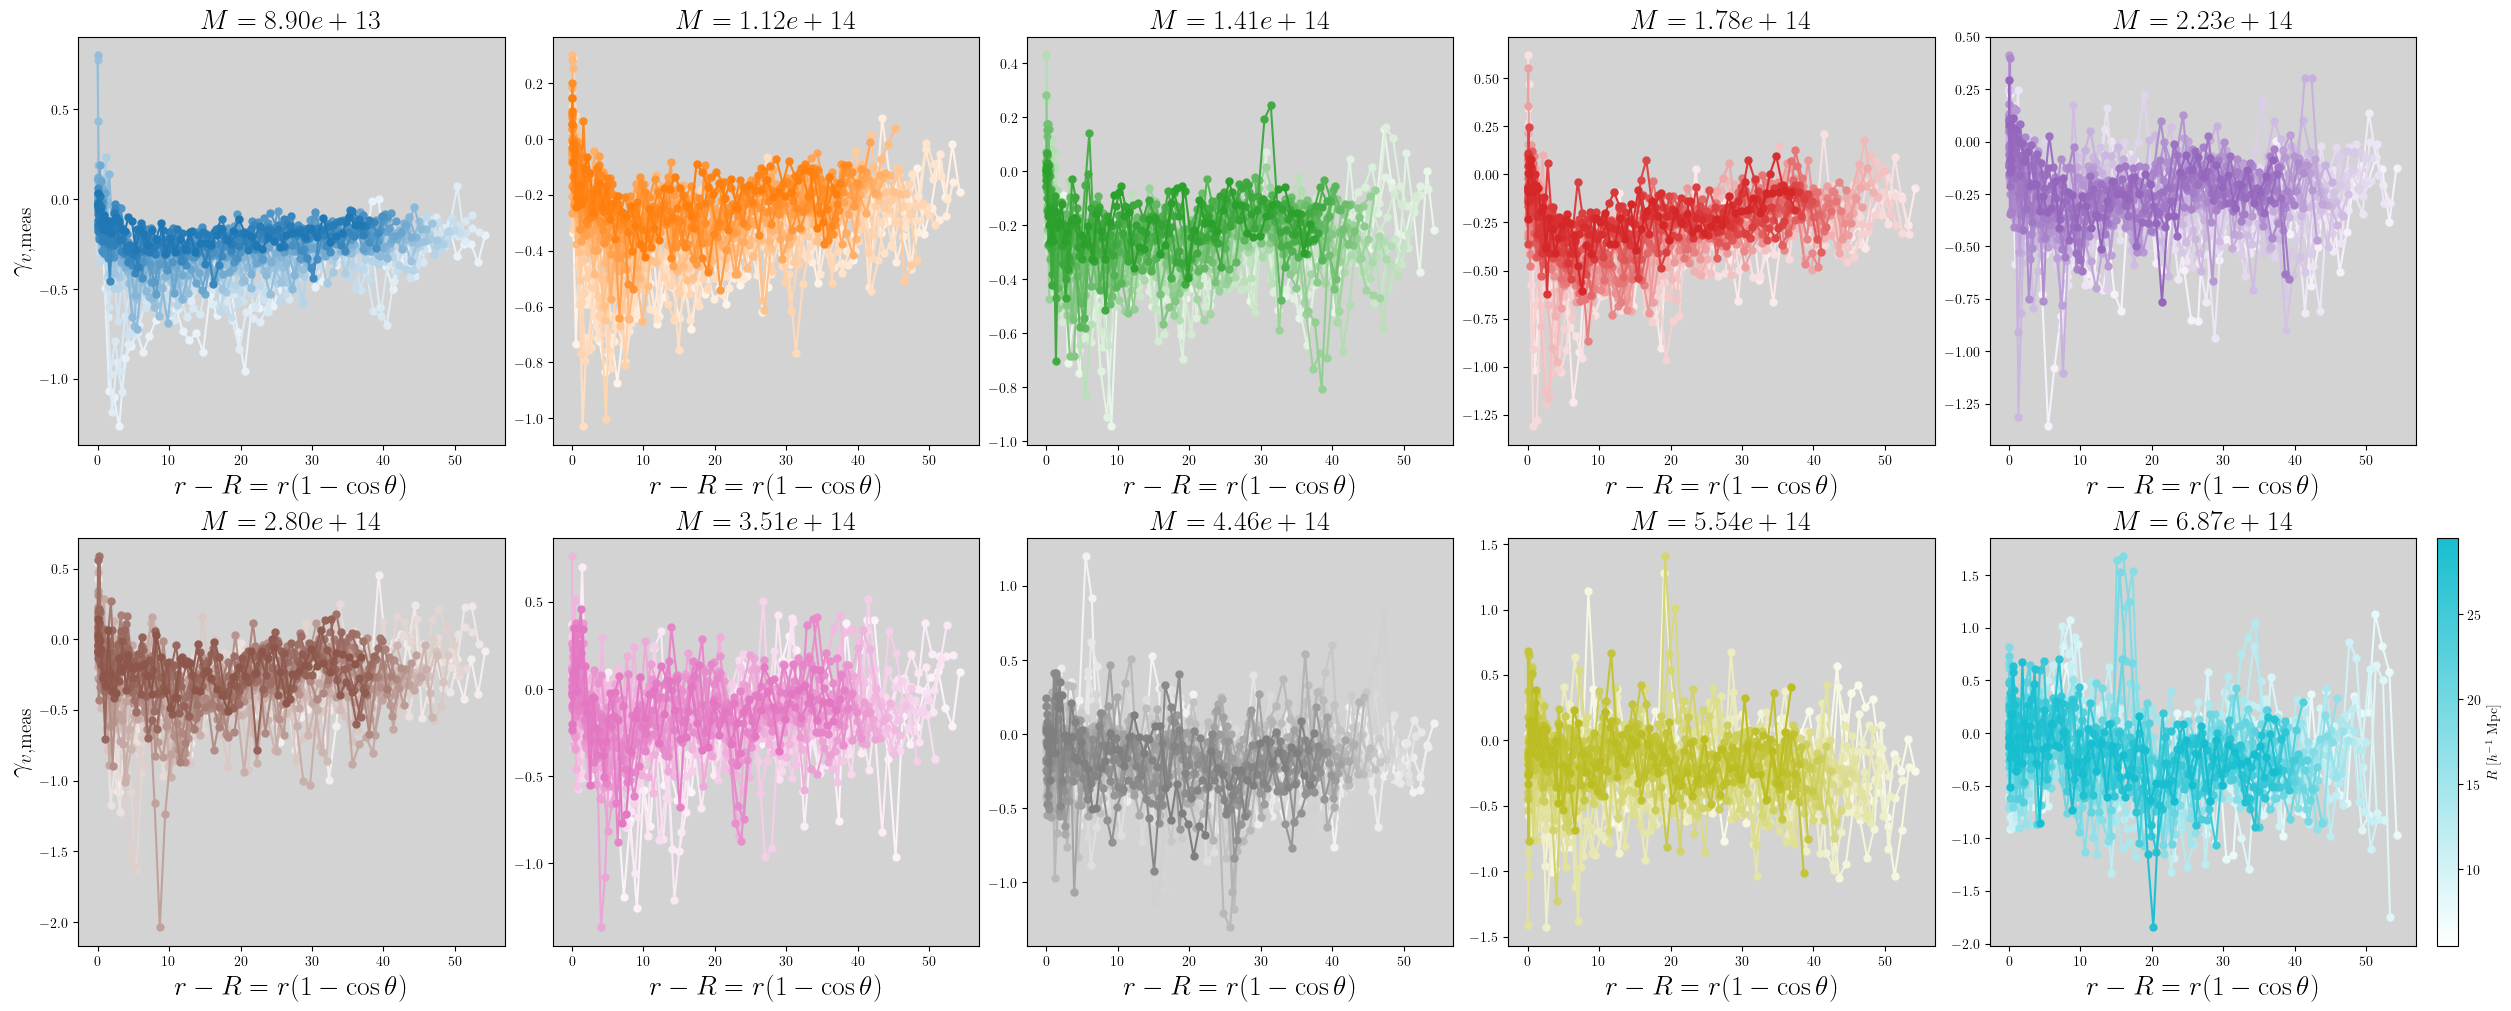

In [101]:
import math
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ncols = math.ceil(len(Mvirs2) / 2)   # row 1 length; row 2 = len(Mvirs2)//2
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=False)
ax = axes.flatten()                    # index linearly: ax[k] as before

nu = 6
xis = STpars[:, :, :, 0]
alphas = STpars[:, :, :, 2]
omegas = STpars[:, :, :, 1]
deltas = alphas / np.sqrt(1+alphas**2)

betanu = np.sqrt(nu/np.pi) * scipy.special.gamma((nu - 1)/2)/scipy.special.gamma((nu)/2) 
sigmaz = np.sqrt(nu/(nu-2) - (betanu*deltas)**2)

sigma_v = omegas * sigmaz

gamma_v = (betanu*deltas)/sigmaz**3 * ( nu*(3-deltas**2)/(nu-3) - 3*nu/(nu-2) + 2*(betanu*deltas)**2 )

ys     =  meas_skew #alphas #gamma_v
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)

        
        ax[k].plot(r - R, ys[k, j], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R = r(1-\cos\theta)$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        #ax[k].set_xscale('log')
        #ax[k].set_ylim((0, 2))
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)
    
# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\gamma_{v, \rm meas}$', fontsize=20)
axes[1, 0].set_ylabel(r'$\gamma_{v, \rm meas}$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

In [11]:
from scipy.stats import skew

meas_skew = np.zeros((len(Mvirs2), len(R_cens), len(rlos_cens)))

for k in range(len(Mvirs2)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens)):
            std = skew(data_dict[k][j][i+59]['vpeclos'])
            meas_skew[k, j, i] = std

In [43]:
def Delta(x, x_0, x_t, Delta_t):
    #x_0, x_t, Delta_t = pars
    return np.maximum( -(x-x_0)/x_t, -Delta_t)

In [ ]:
import math
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

ncols = math.ceil(len(Mvirs2) / 2)   # row 1 length; row 2 = len(Mvirs2)//2
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 10), layout='constrained', sharey=False)
ax = axes.flatten()                    # index linearly: ax[k] as before

nu = 6
xis = STpars[:, :, :, 0]
xi_e = STerrs[:, :, :, 0]
alphas = STpars[:, :, :, 2]
omegas = STpars[:, :, :, 1]
deltas = alphas / np.sqrt(1+alphas**2)

betanu = np.sqrt(nu/np.pi) * scipy.special.gamma((nu - 1)/2)/scipy.special.gamma((nu)/2) 
sigmaz = np.sqrt(nu/(nu-2) - (betanu*deltas)**2)

sigma_v = omegas * sigmaz

gamma_v = (betanu*deltas)/sigmaz**3 * ( nu*(3-deltas**2)/(nu-3) - 3*nu/(nu-2) + 2*(betanu*deltas)**2 )

#ys     = meas_skew
colors = plt.cm.tab10.colors
nR     = len(R_cens)
nlos   = len(rlos_cens)

Deltas = np.zeros((len(Mvirs2), nR, nlos))

r_grid = np.sqrt(R_cens[:, None]**2 + rlos_cens[None, :]**2)
x_grid = r_grid - R_cens[:, None]

xs = np.logspace(np.log10(3e-3), np.log10(60), 100)

delta_pars = np.zeros((len(Mvirs2), 1))
delta_errs = np.zeros((len(Mvirs2), 1))

mins = np.zeros(len(Mvirs2))

p00 = [1]
p01  = []

for k in range(len(Mvirs2)):
    cmap  = mcolors.LinearSegmentedColormap.from_list(f"cmap_{k}", ['white', colors[k]])
    cmaps = cmap(np.linspace(0.1, 1.0, nR))
    for j in range(nR):
        R    = R_cens[j]
        rlos = rlos_cens
        r    = np.sqrt(R**2 + rlos**2)
        sin = rlos / r

        mode = RBinterp(np.log10(Mvirs2[k]), r).squeeze()*sin 

        ys = -(mode - xis[k, j])#/meas_sigv[k, j]
        Deltas[k, j] = ys

        mask = np.abs(alphas[k, j]) < 10

        ax[k].plot((r-R)[mask], ys[mask], c=cmaps[j], marker='o', markersize=5)
        ax[k].set_xlabel(r"$r-R$", fontsize=20)
        ax[k].set_facecolor('lightgray')
        ax[k].set_xscale('log')
        ax[k].set_title(rf"$M={Mvirs2[k]:.2e}$", fontsize=20)
        ax[k].set_ylim((-600, 800))
    #ax[k].axhline(np.mean(Deltas[k, :, :3]), c='g', ls='--')
    #print(np.mean(Deltas[k, :, :3]))
    
    # p, c = curve_fit(lambda x, x_0, x_t: Delta(x, x_0, x_t, 170), x_grid.flatten(), Deltas[k].flatten(), p0=[0.1, 15], bounds=[(0.001, 0.001), (np.inf, np.inf)],  maxfev=10_000)
    # #delta_pars[k] = p
    # ax[k].plot(xs, Delta(xs, *p, 170), c='k', ls='-')
    #ax[k].axvline(p[0], c='k', ls='--')
    #ax[k].axvline(p[1], c='k', ls='--')

    # p, c = curve_fit(lambda x, C: 170*x/(1+x)+C, x_grid.flatten(), Deltas[k].flatten(), p0=[-50],  maxfev=10_000)

    mins[k] = np.min(Deltas[k, :, 0])

    # p, c = curve_fit(lambda x, A: A*x/(1+x)+mins[k], x_grid.flatten(), Deltas[k].flatten(), sigma=xi_e[k].flatten(), p0=[170],  maxfev=10_000)
    # delta_pars[k] = p
    # ax[k].plot(xs,  p*xs/(1+xs)+mins[k], c='k', ls='-', label='Fit to panel')

    if k == 0:
        p0 = p00
    else:
        p0 = p01

    p, c = curve_fit(lambda x, a: 170*x/(a+x), x_grid.flatten(), Deltas[k].flatten(),  p0=p0, bounds=[(0), (np.inf)],  maxfev=10_000)
    delta_pars[k] = p
    delta_errs[k] = np.sqrt(np.diag(c))
    p01 = p

    ax[k].plot(xs,  170*xs/(p+xs), c='k', ls='-', label='Fit to panel')
    ax[k].plot(xs,  170*xs/(1+xs), c='cyan', ls='-', label='No MD')

    da = plawc(Mvirs2[k]/1e14, *delta_mpars[0][0])
    ax[k].plot(xs,  170*xs/(da+xs), c='k', ls='--', label='smooth model')

    if k == 0:
        ax[k].legend(fontsize=10)

# Hide unused axes when len(Mvirs2) is odd
for k in range(len(Mvirs2), nrows * ncols):
    ax[k].set_visible(False)

# ylabel for the first column of each row
axes[0, 0].set_ylabel(r'$\Delta\equiv\xi_{\rm ST}-v_{\rm r, peak}(r)\sin\theta$', fontsize=20)
axes[1, 0].set_ylabel(r'$\Delta\equiv\xi_{\rm ST}-v_{\rm r, peak}(r)\sin\theta$', fontsize=20)

Norm = Normalize(vmin=min(R_cens), vmax=max(R_cens))
sm   = ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[len(Mvirs2) - 1])  # attach to last used axis
cbar.set_label(r"$R \ [h^{-1}$ Mpc]")

NameError: name 'Mvirs2' is not defined

In [27]:
def plot_dependence(x_quant, y_quants, y_errs, xlabel, ylabels, fitfuncs=None, pivot=1, masks=None):
    ncol = y_quants.shape[-1]

    fig, axes = plt.subplots(1, ncol, figsize=(ncol*5, 5), layout='constrained')

    if y_quants.shape[-1] > 1:
        pars = []

        for i, ax in enumerate(axes):
            ax.errorbar(x_quant, y_quants[:, i], y_errs[:, i], fmt='o-')
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabels[i])

            if fitfuncs:
                p, c = curve_fit(fitfuncs[i], x_quant[masks[i]]/pivot, y_quants[:, i][masks[i]], sigma=y_errs[:, i][masks[i]], absolute_sigma=False, maxfev=10_000)

                xs = np.linspace(x_quant[0]-0.1*x_quant[0], x_quant[-1]+0.1*x_quant[-1], 100)
                ax.plot(xs, fitfuncs[i](xs/pivot, *p))

                pars.append([p])
    else:
        pars = []

        i = 0
        axes.errorbar(x_quant, y_quants[:, i], y_errs[:, i], fmt='o-')
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabels[i])

        if fitfuncs:
            p, c = curve_fit(fitfuncs[i], x_quant[masks[i]]/pivot, y_quants[:, i][masks[i]], sigma=y_errs[:, i][masks[i]], absolute_sigma=False, maxfev=10_000)

            xs = np.linspace(x_quant[0]-0.1*x_quant[0], x_quant[-1]+0.1*x_quant[-1], 100)
            axes.plot(xs, fitfuncs[i](xs/pivot, *p))

            pars.append([p])
    
    if fitfuncs:
        return fig, axes, pars
    else:

        return fig, axes

(0.0, 15.0)

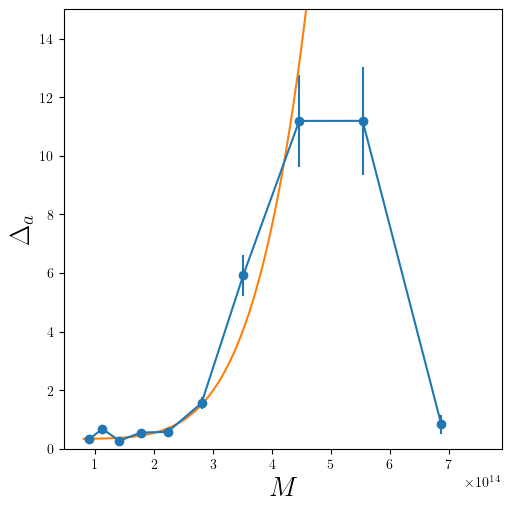

In [43]:
fig, ax, delta_mpars = plot_dependence(Mvirs2, delta_pars, delta_errs, r'$M$', [r'$\Delta_a$'], [plawc], 1e14, [Mvirs2<Mvirs2[-2]])
ax.set_ylim((0, 15))

In [47]:
delta_mpars

[[array([0.00573437, 5.15650306, 0.34117687])]]

In [48]:
#delta_mpars = np.array([270.70435268, 0.32911683, 57.57261054, 0.88739539]) 
delta_mpars = delta_mpars[0][0]

def Delta(x, M, pars):
    a_p, a_s, a_c = pars

    M_p = 1e14

    A = 170
    a = plawc(M/M_p, a_p, a_s, a_c)

    D = A*x/(a+x)

    return D

def vlos_mode(R, rlos, M):
    r    = np.sqrt(R**2 + rlos**2)
    sin = rlos / r

    mode = RBinterp(np.log10(M), r).squeeze()*sin 

    return mode

In [142]:
from scipy import stats, interpolate, optimize
from scipy.special import gamma
import matplotlib.gridspec as gridspec
 
# ── Fixed ν ──────────────────────────────────────────────────────────────────
NU = 6
 
 
# ─────────────────────────────────────────────────────────────────────────────
# 1.  Analytic helpers for the standardised skew-t  ST(0, 1, α, ν)
# ─────────────────────────────────────────────────────────────────────────────
 
def _b_nu(nu: float) -> float:
    """b_ν = √ν · Γ((ν-1)/2) / (√π · Γ(ν/2))"""
    return np.sqrt(nu) * gamma((nu - 1) / 2.0) / (np.sqrt(np.pi) * gamma(nu / 2.0))
 
_B6 = _b_nu(NU)   # ≈ 0.9186
 
 
def sigma_star(alpha: float | np.ndarray, nu: float = NU) -> float | np.ndarray:
    """
    Analytic std-dev of the standardised skew-t ST(0, 1, α, ν).
 
        σ*(α) = √[ ν/(ν-2) − δ² b_ν² ]   where δ = α/√(1+α²)
    """
    delta = alpha / np.sqrt(1.0 + alpha**2)
    b     = _b_nu(nu)
    return np.sqrt(np.maximum(nu / (nu - 2.0) - (delta * b)**2, 1e-14))
 
 
def _standardised_skewt_logpdf(t: np.ndarray, alpha: float,
                                nu: float = NU) -> np.ndarray:
    """Log-PDF of ST(0, 1, α, ν) evaluated at t."""
    return (stats.t.logpdf(t, df=nu)
            + stats.t.logcdf(alpha * t * np.sqrt((nu + 1.0) / (nu + t**2)),
                             df=nu + 1.0))
 
 
# ─────────────────────────────────────────────────────────────────────────────
# 2.  Precompute mode grid  m*(α)  once at import time
# ─────────────────────────────────────────────────────────────────────────────
 
def _compute_mode_star(alpha: float, nu: float = NU) -> float:
    """Mode of ST(0, 1, α, ν) found by 1-D bounded minimisation."""
    if abs(alpha) < 1e-9:
        return 0.0
    result = optimize.minimize_scalar(
        lambda t: -_standardised_skewt_logpdf(np.array([t]), alpha, nu)[0],
        bounds=(-15.0, 15.0), method="bounded",
        options={"xatol": 1e-10}
    )
    return float(result.x)
 
 
# Symmetric grid — finer near zero where curvature is largest
_ALPHA_GRID = np.sign(
    np.linspace(-1, 1, 401)
) * np.linspace(0, 30, 401)**1          # 0..30 mapped nonlinearly
_ALPHA_GRID = np.unique(
    np.concatenate([
        np.linspace(-30, -0.5, 180),
        np.linspace(-0.5, 0.5, 101),    # dense near 0
        np.linspace(0.5, 30, 180),
    ])
)
 
print("Precomputing mode grid … ", end="", flush=True)
_MODE_STAR_GRID = np.array([_compute_mode_star(a) for a in _ALPHA_GRID])
print("done.")
 
_mode_star_interp = interpolate.PchipInterpolator(_ALPHA_GRID, _MODE_STAR_GRID,
                                                  extrapolate=True)
 
def mode_star(alpha: float | np.ndarray) -> float | np.ndarray:
    """Mode of ST(0, 1, α, ν=6) via precomputed PCHIP interpolation."""
    return _mode_star_interp(alpha)
 
 
# ─────────────────────────────────────────────────────────────────────────────
# 3.  Core inversion:  (m0, σ_v, Δ) → (ξ, ω, α)
# ─────────────────────────────────────────────────────────────────────────────
 
def invert_skewt_params(
    m0: float, sigma_v: float, Delta: float,
    nu: float = NU, tol: float = 1e-11
) -> tuple[float, float, float]:
    """
    Invert skew-t moments to distribution parameters.
 
    Parameters
    ----------
    m0      : predicted mode of P(v | x, M)
    sigma_v : predicted dispersion (std dev)
    Delta   : m0 − ξ  (mode minus location parameter)
    nu      : degrees of freedom (default 6)
    tol     : tolerance for Brent root-finding
 
    Returns
    -------
    xi, omega, alpha
    """
    # Step 1 — location is trivial
    xi = m0 - Delta #
 
    # Edge case: symmetric bin
    if abs(Delta) < 1e-10 * sigma_v:
        omega = sigma_v / sigma_star(0.0, nu)
        return xi, float(omega), 0.0
 
    sign    = -np.sign(Delta)   # Δ < 0  ↔  α < 0
    R_target = abs(Delta) / sigma_v
 
    # R(α) = |m*(α)| / σ*(α)  — solve on the correct sign branch
    alpha_probe = sign * np.linspace(0.02, 30.0, 800)
    R_probe     = (np.abs(_mode_star_interp(alpha_probe))
                   / sigma_star(alpha_probe, nu))
    diffs = R_probe - R_target
 
    sign_changes = np.where(np.diff(np.sign(diffs)))[0]
 
    if len(sign_changes) == 0:
        # R_target beyond grid maximum → clamp
        alpha_sol = float(alpha_probe[np.argmin(np.abs(diffs))])
    else:
        i = sign_changes[0]
        a_lo, a_hi = sorted([alpha_probe[i], alpha_probe[i + 1]])
        alpha_sol = optimize.brentq(
            lambda a: abs(_mode_star_interp(a)) / sigma_star(a, nu) - R_target,
            a_lo, a_hi, xtol=tol, maxiter=200
        )
 
    omega = sigma_v / float(sigma_star(alpha_sol, nu))
    return xi, omega, float(alpha_sol)
 
 
# ─────────────────────────────────────────────────────────────────────────────
# 4.  Skew-t PDF
# ─────────────────────────────────────────────────────────────────────────────
 
def skewt_pdf(
    v: np.ndarray,
    xi: float, omega: float, alpha: float,
    nu: float = NU
) -> np.ndarray:
    """
    PDF of skew-t(ξ, ω, α, ν):
 
        f(v) = (2/ω) t_ν(z) T_{ν+1}( α z √[(ν+1)/(ν+z²)] )
 
    where z = (v − ξ)/ω.
    """
    v = np.asarray(v, dtype=float)
    z = (v - xi) / omega
    return (2.0 / omega
            * stats.t.pdf(z, df=nu)
            * stats.t.cdf(alpha * z * np.sqrt((nu + 1.0) / (nu + z**2)),
                          df=nu + 1.0))
 
 
# ─────────────────────────────────────────────────────────────────────────────
# 5.  Public interface: P(v | r−R, M)
# ─────────────────────────────────────────────────────────────────────────────
 
def skewt_distribution(
    v:     np.ndarray,
    R:     float,
    rlos:  float,
    M:     float,
    nu:    float = NU,
) -> tuple[np.ndarray, dict]:

    r         = np.sqrt(R**2 + rlos**2)
    r_minus_R = r - R

    m0      = float(vlos_mode(R, rlos, M))
    sigma_v = float(sig_vm(r_minus_R, M, rho_pars))
    Delt    = float(-Delta(r_minus_R, M, delta_mpars)) * np.sign(rlos)  # ← enforce odd parity

    xi, omega, alpha = invert_skewt_params(m0, sigma_v, Delt, nu=nu)
    pdf = skewt_pdf(np.asarray(v, dtype=float), xi, omega, alpha, nu=nu)

    return pdf, {"xi": xi, "omega": omega, "alpha": alpha,
                 "m0": m0, "sigma_v": sigma_v, "Delta": Delt}


Precomputing mode grid … done.


In [221]:
import numpy as np
from scipy.stats import t as student_t
from scipy.special import gamma
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

class SkewTInterpolator:
    """
    Pre-computes the relationship between (Delta / sigma_v) and (omega, alpha)
    for a Skew-T distribution with fixed degrees of freedom.
    """
    def __init__(self, nu=6, alpha_bounds=(-15, 15), pts=500):
        self.nu = nu
        alphas = np.linspace(alpha_bounds[0], alpha_bounds[1], pts)
        
        R_vals = np.zeros(pts)
        sigZ_vals = np.zeros(pts)
        
        for i, alpha in enumerate(alphas):
            # 1. Standard Deviation of standard Skew-T (xi=0, omega=1)
            delta = alpha / np.sqrt(1 + alpha**2)
            mu_z = delta * np.sqrt(nu / np.pi) * (gamma((nu - 1) / 2) / gamma(nu / 2))
            var_z = (nu / (nu - 2)) - mu_z**2
            sig_z = np.sqrt(var_z)
            
            # 2. Mode of standard Skew-T
            def neg_pdf(z):
                arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
                return -2 * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)
            
            # Search bounded around the mean
            res = minimize_scalar(neg_pdf, bounds=(mu_z - 3, mu_z + 3), method='bounded')
            m_z = res.x
            
            # 3. Ratio R = Delta / sigma_v for standard distribution
            # Delta_z = xi_z - m_z = 0 - m_z = -m_z
            R_vals[i] = -m_z / sig_z
            sigZ_vals[i] = sig_z
            
        # Isolate the monotonic region of R(alpha) to build a robust inverse interpolator
        max_idx = np.argmax(R_vals)
        min_idx = np.argmin(R_vals)
        valid_idx = np.arange(min(min_idx, max_idx), max(min_idx, max_idx) + 1)
        
        valid_R = R_vals[valid_idx]
        valid_alphas = alphas[valid_idx]
        
        # Ensure x is strictly increasing for interp1d
        if valid_R[-1] < valid_R[0]:
            valid_R = valid_R[::-1]
            valid_alphas = valid_alphas[::-1]
            
        # Interpolator 1: Ratio -> alpha
        self.R_to_alpha = interp1d(valid_R, valid_alphas, kind='linear', 
                                   bounds_error=False, 
                                   fill_value=(valid_alphas[0], valid_alphas[-1]))
        
        # Interpolator 2: alpha -> standard deviation
        self.alpha_to_sigZ = interp1d(alphas, sigZ_vals, kind='linear', 
                                      bounds_error=False, 
                                      fill_value=(sigZ_vals[0], sigZ_vals[-1]))

    def get_skew_params(self, delta, sig_v):
        """Maps physical parameters (Delta, sigma_v) to Skew-T parameters (omega, alpha)"""
        ratio = delta / sig_v
        alpha = self.R_to_alpha(ratio)
        sig_z = self.alpha_to_sigZ(alpha)
        omega = sig_v / sig_z
        return omega, alpha
    
# Instantiate this globally so it isn't rebuilt on every function call
skew_interp = SkewTInterpolator(nu=6)

def Pv_R_rlos(v, R, rlos, M, pars_delta=delta_mpars, pars_sig=rho_pars):
    """
    Evaluates P(v | R, rlos, M) modeled as a Skew-T distribution.
    """
    # 1. Coordinate transformations
    r = np.sqrt(R**2 + rlos**2)
    x = r - R
    
    # 2. Evaluate physical quantities via your models
    m0 = vlos_mode(R, rlos, M)
    sig_v = sig_vm(x, M, pars_sig)
    
    # Enforce symmetry: Delta flips sign when rlos is negative
    sign_rlos = np.sign(rlos)
    delta_val = Delta(x, M, pars_delta) * (sign_rlos if sign_rlos != 0 else 1.0)
    
    # 3. Interpolate standard Skew-T parameters
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 4. Location parameter is purely algebraic
    xi = m0 + delta_val
    
    # 5. Evaluate Skew-T PDF
    nu = skew_interp.nu
    z = (v - xi) / omega
    
    # Azzalini's Skew-T formulation: 2 * t.pdf(z) * t.cdf(alpha * z * sqrt...)
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)
    
    return pdf


def vlos_mode_vec(R, rlos, M, RBinterp=RBinterp):
    """
    Vectorized version of vlos_mode guaranteed to work with N-dimensional broadcasted arrays.
    """
    r = np.sqrt(R**2 + rlos**2)
    
    # 1. Safe sine calculation to prevent division by zero at R=0, rlos=0
    # np.where evaluates across the array safely without throwing warnings
    sin = np.where(r == 0, 0.0, rlos / r)
    
    # 2. Broadcast inputs to their shared target shape (e.g., 1, NM, NR, Nrlos)
    logM = np.log10(M)
    logM_b, r_b = np.broadcast_arrays(logM, r)
    
    # 3. Flatten the arrays to 1D for safe interpolation
    flat_logM = logM_b.ravel()
    flat_r = r_b.ravel()
    
    # 4. Evaluate the interpolator point-to-point.
    # Note: Because your original syntax was RBinterp(x, y), I am assuming this is 
    # a scipy.interpolate.RectBivariateSpline (or similar). 
    # Using `grid=False` ensures it evaluates paired coordinates (x[i], y[i]) 
    # rather than building a grid of all possible combinations.
    flat_interp = RBinterp(flat_logM, flat_r, grid=False)
    
    # 5. Reshape back to the broadcasted 4D shape and apply the geometric factor
    mode_interp = flat_interp.reshape(logM_b.shape)
    mode = mode_interp * sin
    
    return mode


def Pv_R_rlos_vec(v, R, rlos, M, pars_delta=delta_mpars, pars_sig=rho_pars):
    """
    Vectorized evaluation of P(v | R, rlos, M).
    Expects 1D arrays for v, R, rlos, M.
    Returns an array of shape (Nv, NM, NR, Nrlos).
    """
    # 1. Expand dimensions to create a 4D broadcastable grid
    # v shape:    (Nv, 1, 1, 1)
    # M shape:    (1, NM, 1, 1)
    # R shape:    (1, 1, NR, 1)
    # rlos shape: (1, 1, 1, Nrlos)
    v_b    = np.asarray(v)[:, None, None, None]
    M_b    = np.asarray(M)[None, :, None, None]
    R_b    = np.asarray(R)[None, None, :, None]
    rlos_b = np.asarray(rlos)[None, None, None, :]
    
    # 2. Coordinate transformations (Shape: 1, 1, NR, Nrlos)
    r = np.sqrt(R_b**2 + rlos_b**2)
    x = r - R_b
    
    # 3. Evaluate physical quantities
    # Note: Your underlying vlos_mode, sig_vm, and Delta functions 
    # will naturally inherit these broadcasted (1, NM, NR, Nrlos) shapes
    m0    = vlos_mode_vec(R_b, rlos_b, M_b)
    sig_v = sig_vm(x, M_b, pars_sig)
    
    # Enforce symmetry using np.where for array-safe conditionals
    sign_rlos = np.sign(rlos_b)
    sign_rlos = np.where(sign_rlos == 0, 1.0, sign_rlos)
    delta_val = Delta(x, M_b, pars_delta) * sign_rlos
    
    # 4. Interpolate standard Skew-T parameters
    # scipy.interpolate.interp1d natively supports N-dimensional arrays
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 5. Location parameter
    xi = m0 + delta_val
    
    # 6. Evaluate Skew-T PDF
    # z shape becomes (Nv, NM, NR, Nrlos) because v_b broadcasts against xi/omega
    nu = skew_interp.nu
    z = (v_b - xi) / omega
    
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * student_t.pdf(z, nu) * student_t.cdf(arg, nu + 1)
    
    return pdf

In [222]:
test = Pv_R_rlos_vec(vcens, R_cens, rlos_cens, Mvirs2)
test.shape

(50, 10, 25, 60)

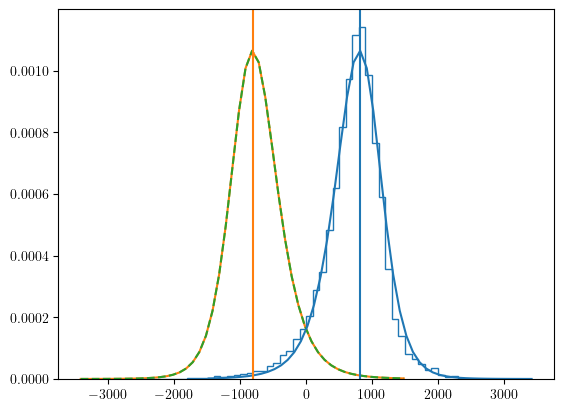

In [96]:
vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])

R_ind = 0
rl_ind = 10

ptest = Pv_R_rlos(vcens, R_cens[R_ind], rlos_cens[rl_ind], Mvirs2[0])
ntest = Pv_R_rlos(vcens, R_cens[R_ind], -rlos_cens[rl_ind], Mvirs2[0])

hflo = a*H*rlos_cens[rl_ind]/h

plt.plot(vcens+hflo, ptest)
plt.plot(vcens-hflo, ntest)
plt.plot(vcens-hflo, np.flip(ptest), ls='--')
hist = plt.hist(data_dict[0][R_ind][rl_ind+60]['vphyslos'], bins=vedges, density=True, histtype='step', color='C0')

plt.axvline(vlos_mode(R_cens[R_ind], rlos_cens[rl_ind], Mvirs2[0])+hflo, c="C0")
plt.axvline(-(vlos_mode(R_cens[R_ind], rlos_cens[rl_ind], Mvirs2[0])+hflo), c="C1")

In [207]:
for k in range(0, len(Mvirs2), 9):
    print(k)

0
9


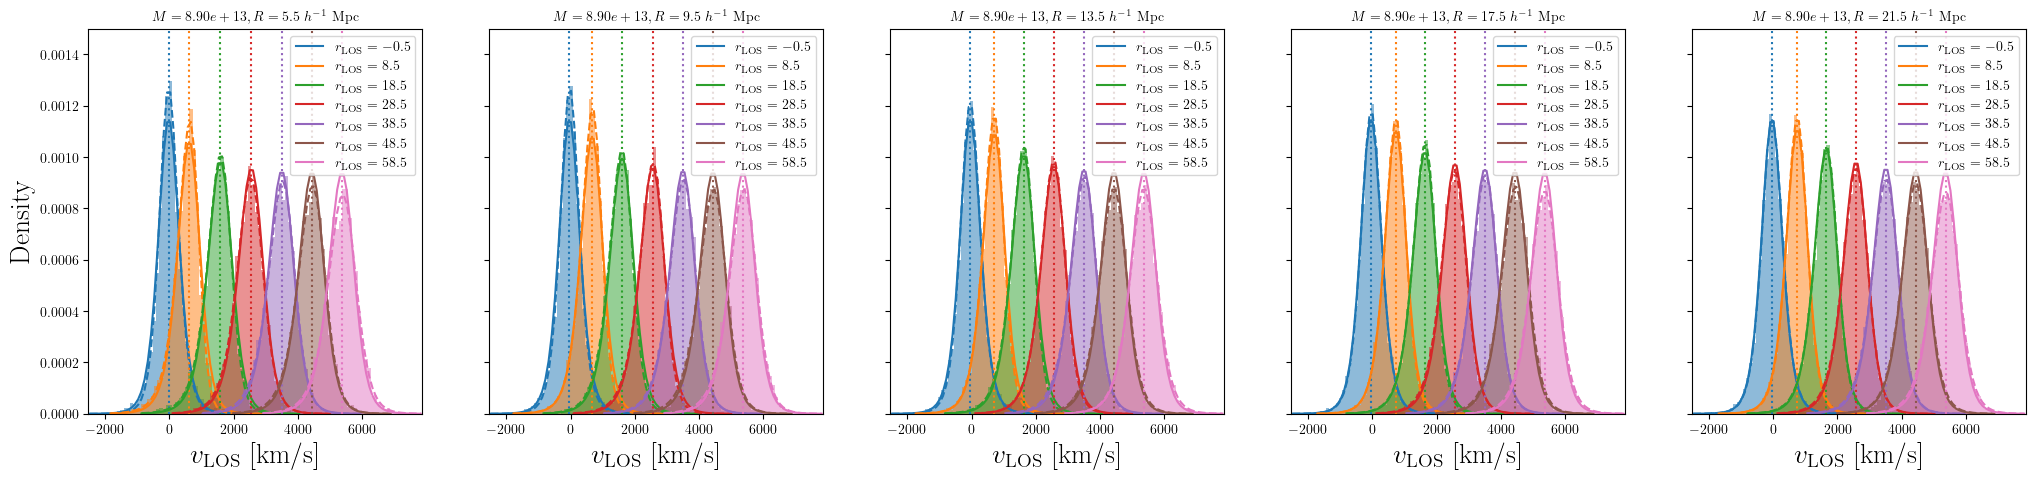

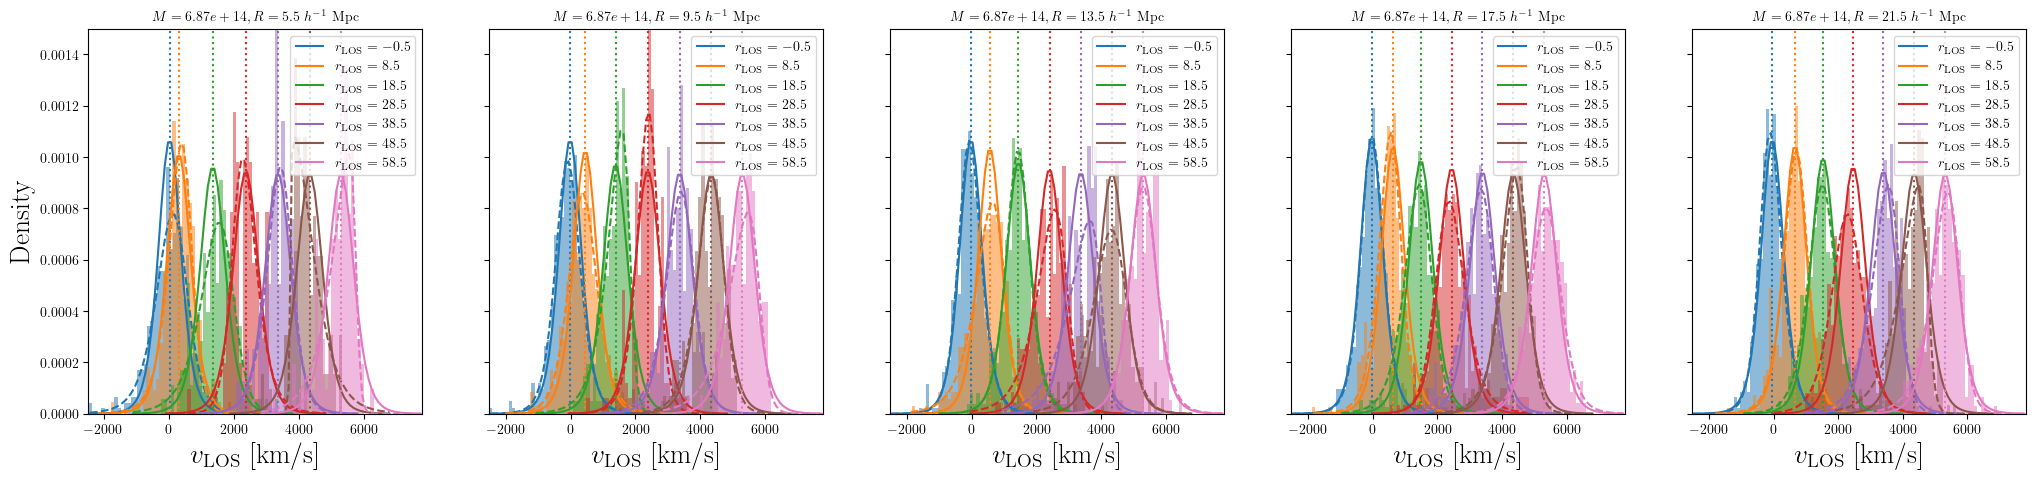

In [238]:

# test fit to P(vlos|R, rlos)
R_inds    = [0, 4, 8, 12, 16]
rlos_inds = [0, 9, 19, 29, 39, 49, 59]

nu=6

for k in range(0, len(Mvirs2), 9):
    
    fig, ax = plt.subplots(1, len(R_inds), figsize=(5*len(R_inds), 5), sharey=True)

    for j in R_inds:
        for i in rlos_inds:

            r = np.sqrt(R_cens[j]**2 + rlos_cens_dual[i+59]**2)
            theta = np.arctan2(rlos_cens_dual[i+59], R_cens[j])
            sin = np.sin(theta)

            mu = RBinterp(np.log10(Mvirs2[k]), r).squeeze()*sin
            peak = mu + a*H*rlos_cens_dual[i+59]/h

            ve = np.linspace(peak-2500, peak+2500, 50+1)
            vc = 0.5*(ve[1:] + ve[:-1])

            test_hist, bins, _ = ax[j//4].hist(data_dict[k][j][i+59]['vphyslos'], bins=ve, density=True, alpha=0.5, color=f'C{i//9}')
            cens = 0.5*(bins[1:] + bins[:-1])

            P = Pv_R_rlos(cens-a*H*rlos_cens_dual[i+59]/h, R_cens[j], rlos_cens_dual[i+59], Mvirs2[k], res.x[:3], res.x[3:]) 
            #Pv_R_rlos_smooth(cens-a*H*rlos_cens_dual[i+59]/h, R_cens[j], rlos_cens_dual[i+59], Mvirs2[k], res.x)

            ax[j//4].plot(cens, P, c=f'C{i//9}', label=rf'$r_{{\rm LOS}}={rlos_cens_dual[i+59]}$')
            ax[j//4].plot(cens, skewed_t_pdf(cens-a*H*rlos_cens_dual[i+59]/h, STpars[k, j, i, 0], STpars[k, j, i, 1], STpars[k, j, i, 2], nu), c=f'C{i//9}', ls ='--',)


            ax[j//4].axvline(peak, color=f'C{i//9}', ls=':')

            ax[j//4].set_title(rf"$M={Mvirs2[k]:.2e}, R = {R_cens[j]}$ $h^{{-1}}$ Mpc ", fontsize=10)
            ax[j//4].set_xlabel(r"$v_{\rm LOS}$ [km/s]", fontsize=20)
            ax[0].set_ylabel(r"Density", fontsize=20)
            ax[j//4].margins(x=0) 

            #if i == rlos_inds[0]:
            ax[j//4].legend()
            ax[j//4].set_ylim((0, 0.0015))



In [227]:
Nv_R_rlos = np.zeros((len(vcens), len(Mvirs), len(R_cens), len(rlos_cens)))

for k in range(len(Mvirs)):
    for j in range(len(R_cens)):
        for i in range(len(rlos_cens)):

            nhist, bins = np.histogram(data_dict[k][j][i+59]['vpeclos'], bins=vedges, density=False)
            Nv_R_rlos[:, k, j, i] = nhist

In [235]:
# re-fit model to histograms
init_pars = np.array([0.00573437, 5.15650306, 0.34117687, -0.03055477,  0.34374933, 16.46892317])

Bounds = [(np.min((0, np.sign(par)*np.inf)), np.max((0, np.sign(par)*np.inf))) for par in init_pars]


def poisson_llh_vec(pars):
    """
    Nv_R shape assumed: (Nv, NR, NM)
    """
    D_pars = pars[:3]
    S_pars = pars[3:]

    # (Nv, NR, NM)
    P   = Pv_R_rlos_vec(vcens, R_cens, rlos_cens, Mvirs, D_pars, S_pars) 
    dv  = np.diff(vcens)[0]
    # total counts per (R, rlos, M): (1, NR, NM, Nrlos)
    N   = Nv_R_rlos.sum(axis=0, keepdims=True)
    #print(P.shape, N.shape, dv.shape)
    lam = P * dv * N
    log_likelihood = np.sum(scipy.stats.poisson.logpmf(k=Nv_R_rlos, mu=lam))
    return log_likelihood

tlh = poisson_llh_vec(init_pars)
tlh

np.float64(-1582807.856587768)

In [237]:
# MLE 
res = scipy.optimize.minimize(lambda p: -poisson_llh_vec(p), init_pars, bounds=Bounds, method='nelder-mead')
print("Initial: ", init_pars) 
print("MLE: ", res.x)

Initial:  [ 5.73437000e-03  5.15650306e+00  3.41176870e-01 -3.05547700e-02
  3.43749330e-01  1.64689232e+01]
MLE:  [ 0.05500412  4.0531341   0.88963626 -0.01736264  0.35866467 10.15266252]


In [ ]:
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1539984.8298099888
             x: [ 5.500e-02  4.053e+00  8.896e-01 -1.736e-02  3.587e-01
                  1.015e+01]
           nit: 541
          nfev: 837
 final_simplex: (array([[ 5.500e-02,  4.053e+00, ...,  3.587e-01,
                         1.015e+01],
                       [ 5.501e-02,  4.053e+00, ...,  3.587e-01,
                         1.015e+01],
                       ...,
                       [ 5.500e-02,  4.053e+00, ...,  3.587e-01,
                         1.015e+01],
                       [ 5.500e-02,  4.053e+00, ...,  3.587e-01,
                         1.015e+01]]), array([ 1.540e+06,  1.540e+06,  1.540e+06,  1.540e+06,
                        1.540e+06,  1.540e+06,  1.540e+06]))

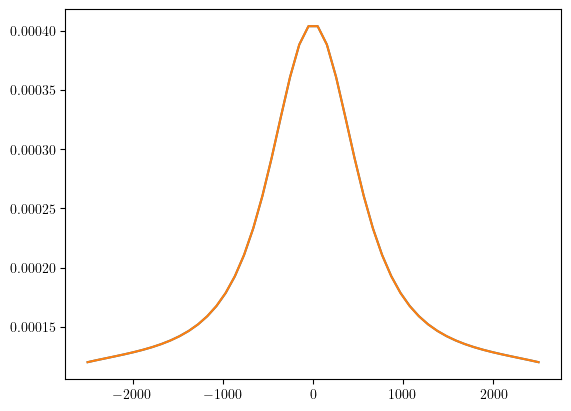

In [239]:
def Pv_R(vphys, R, M):
    rho_g = 0.014  # h^3 Mpc^-3 mean galaxy number density in MDPL2

    # rlos integration range
    rlos_max = 40
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(2 * rlos_max + 1))
    rlos_vals = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    Pvlos_interp_list = []

    for j, rlos in enumerate(rlos_vals):
        hflo = a * H * rlos / h

        ve = np.linspace(vlos_mode(R, rlos, M)-2500, vlos_mode(R, rlos, M)+2500, 101)
        vc = 0.5 * (ve[1:] + ve[:-1])

        # ── replaced Pv_R_rlos_smooth ──────────────────────────────────────
        Pvlos = Pv_R_rlos(vc, R, rlos, M, res.x[:3], res.x[3:])
        # ──────────────────────────────────────────────────────────────────

        interp_func = interp1d(
            vc + hflo, Pvlos, kind="cubic", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vphys)          # shape: (len(vphys),)
        Pvlos_interp_list.append(interpolated)

    # shape: (len(vphys), len(rlos_vals))
    Pvlos_interp = np.array(Pvlos_interp_list).T

    r3d    = np.sqrt(R**2 + rlos_vals**2)
    weight = rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1) #dens_interp(np.log10(M), r3d, grid=False).squeeze() #
    #print(weight.shape)
    integrand = Pvlos_interp * weight[np.newaxis, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    return P_out / np.sum(P_out * np.diff(vphys)[0])

vcens = np.linspace(-2500, 2500, 50)

test = Pv_R(vcens, R_cens[0], Mvirs2[0])

plt.plot(vcens, test)
plt.plot(vcens, np.flip(test))
#plt.plot(vcens, 0.5*(test+np.flip(test)))

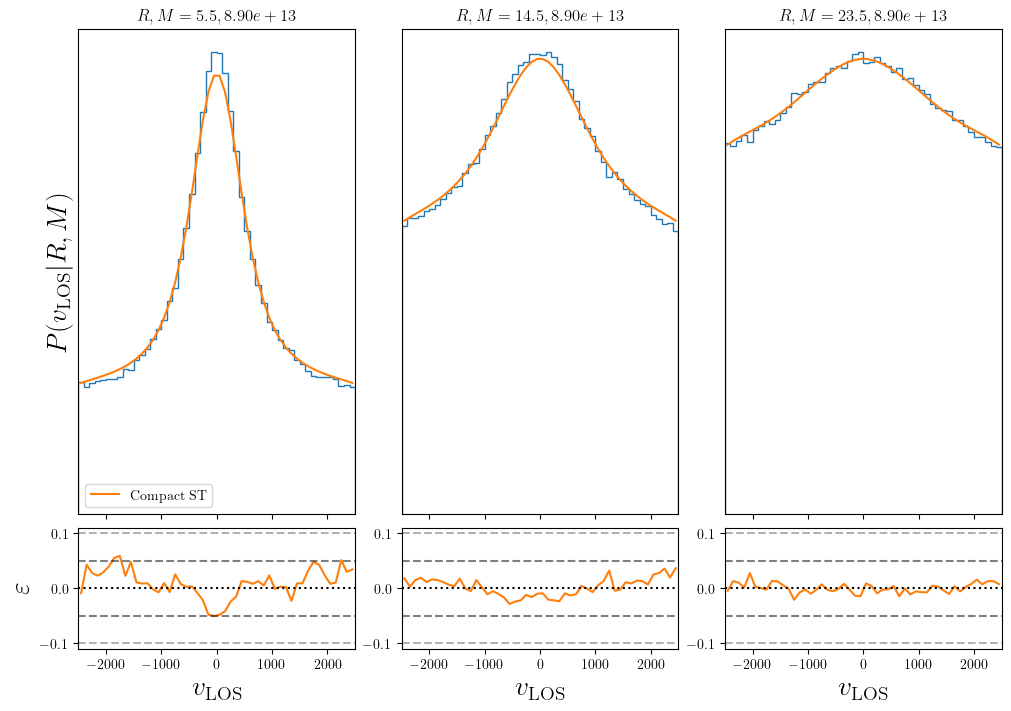

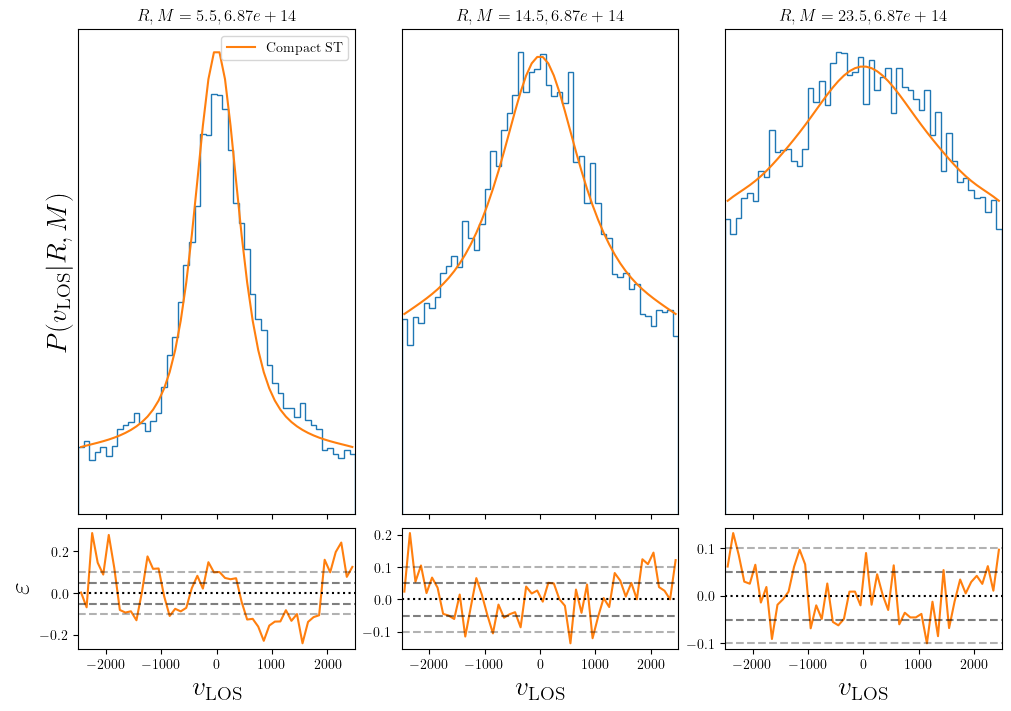

In [240]:
# validate fits on P(v|R, M)
vedges = np.linspace(-2500, 2500, 50+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])

for k in range(0, len(Mvirs2), 9):
    fig, ax = plt.subplots(2, len(R_cens)//7, figsize=(10, 7), layout='constrained', sharex=True, gridspec_kw={'height_ratios': [4, 1]})
    for j in range(0, len(R_cens), 9):
        index = j + k*len(R_cens)

        vphys = np.concatenate([rlos_dict['vphyslos'] for rlos_idx, rlos_dict in data_dict[k][j].items()])
        
        hist, bins, _ = ax[0, j//7].hist(vphys, bins=vedges, density=True, histtype='step') #np.concatenate((vphys,-vphys))

        #hist, bins, _ = ax[0, j//7].hist(vphyslos[index], range=[-2500, 2500], bins='auto', density=True, histtype='step')
        cent = 0.5*(bins[1:] + bins[:-1])

        # ax[0, j//7].plot(cent, P_R_ind_free(cent, j, k), label='Free', c='C1')
        # ax[0, j//7].plot(cent, P_R_ind_fix(cent, j, k), label='Fixed peak', ls='--', c='C1')

        model = 0.5*(Pv_R(vcens, R_cens[j], Mvirs2[k])+np.flip(Pv_R(vcens, R_cens[j], Mvirs2[k])))

        ax[0, j//7].plot(cent, model, label='Compact ST', c='C1')
        ax[1, j//7].plot(cent, (model-hist)/hist, c='C1')
        ax[1, j//7].axhline(0, ls=':', c='k')
        ax[1, j//7].axhline(0.05, ls='--', c='k', alpha=0.5)
        ax[1, j//7].axhline(-0.05, ls='--', c='k', alpha=0.5)
        ax[1, j//7].axhline(0.1, ls='--', c='k', alpha=0.3)
        ax[1, j//7].axhline(-0.1, ls='--', c='k', alpha=0.3)

        ax[1, j//7].set_xlabel(r"$v_{\rm LOS}$", fontsize=20)
        ax[0, j//7].set_yticks([])
        ax[0, j//7].margins(x=0)
        ax[0, j//7].set_title(rf"$R, M = {R_cens[j]}, {Mvirs2[k]:.2e}$")

    ax[0, 0].legend()
    ax[0, 0].set_ylabel(r"$P(v_{\rm LOS}|R, M)$", fontsize=20)
    ax[1, 0].set_ylabel(r"$\varepsilon$")



In [246]:
Nv_R = np.zeros((len(Mvirs2), len(R_cens), len(vcens)))

for k in range(0, len(Mvirs2), 9):
    for j in range(0, len(R_cens), 9):

        vphys = np.concatenate([rlos_dict['vphyslos'] for rlos_idx, rlos_dict in data_dict[k][j].items()])

        nphys, _ = np.histogram(vphys, bins=vedges, density=False)

        Nv_R[k, j] = nphys

In [ ]:
def RG_llh_ind(pars, data, r_ind):
    M, s = pars 

    M_p = 1e14

    dv = (vedges[-1]-vedges[0])/(len(vedges)-1)

    N_avg = np.sum(data) * Pv_R(vcens, R_cens[r_ind], M*M_p) * dv

    sigmasq = N_avg + s**2 * N_avg**2

    chisq = ((data) - N_avg)**2 / sigmasq  

    return - 0.5 * np.sum(chisq + np.log(sigmasq))

In [271]:
test_ms = np.logspace(np.log10(Mvirs2[0]/1e14), np.log10(Mvirs2[-1]/1e14), 30)
llh_prof = np.array([-RG_llh_ind([p, 0], Nv_R[0, 0], 0) for p in test_ms])

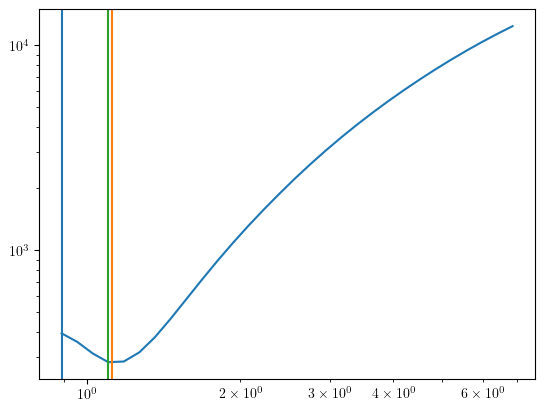

In [275]:
plt.loglog(test_ms, llh_prof)
plt.axvline(Mvirs2[0]/1e14)
plt.axvline(1.12, c='C1')
plt.axvline(test_ms[np.argmin(llh_prof)], c='C2')

In [276]:
np.sum(Nv_R[0, 0])

np.float64(417985.0)

In [263]:
# MLE 
soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, Nv_R[0, 0], 0), [Mvirs2[0]/1e14, 0.01], method='nelder-mead', )
print("Initial: ", [Mvirs2[0]/1e14, 0.01]) 
print("MLE: ", soln.x) 

Initial:  [np.float64(0.89001), 0.01]
MLE:  [1.1331033  0.00847807]


In [ ]:
pars = np.zeros((len(Mvirs), len(R_cens), 2))
#errs = np.zeros((len(Mvirs), len(R_cens), 2))


for k in range(len(Mvirs)):
    for i in range(len(R_cens)):
        p_init = [Mvirs[k]/1e14, 0.01]

        soln = scipy.optimize.minimize(lambda p: -RG_llh_ind(p, Nv_R[k, i], i), p_init, 
                                    #bounds = [(0.5, 12), (-0.1, 0.1)],#, (0, np.inf), (0, np.inf)], 
                                    method='nelder-mead', 
                                    )
        print("Initial: ",p_init) 
        print("MLE: ", soln.x) 
        print(soln.message)

        pars[k, i] = soln.x

0.25989777642947837

In [130]:
# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs2))
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins2)-1):
        mcut = (hcat['mvir'] > mbins2[k]) & (hcat['mvir'] <= mbins2[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

In [171]:
def rebin_halo_catalog(input_filepath, output_filepath, new_mass_bins):
    """
    Re-bins halo-galaxy catalog quantities based on new Mvir bin edges.
    
    Parameters:
    - input_filepath (str): Path to the input HDF5 file.
    - output_filepath (str): Path to save the new re-binned HDF5 file.
    - new_mass_bins (array-like): 1D array of new mass bin edges (e.g., [1e11, 1e12, 1e13, 1e14]).
    """
    quantities = ['Mvir', 'R', 'r', 'rlos', 'vpeclos', 'vphyslos', 'vr', 'vt']
    
    # Step 1: Read and flatten the existing data
    flat_data = {q: [] for q in quantities}
    
    with h5.File(input_filepath, 'r') as hdf_in:
        # Determine the number of original bins by looking at the keys of 'Mvir'
        num_orig_bins = len(hdf_in['Mvir'].keys())
        
        for i in range(num_orig_bins):
            for q in quantities:
                # Read the array and append to our list
                flat_data[q].append(hdf_in[f'{q}/{i}'][()])
                
    # Concatenate lists of arrays into single 1D numpy arrays
    for q in quantities:
        flat_data[q] = np.concatenate(flat_data[q])
        
    # Step 2: Determine new bin assignments
    # np.digitize returns an index representing which bin an element belongs to.
    # Subtracting 1 aligns the output to 0-indexed bins (0, 1, 2, ...).
    bin_indices = np.digitize(flat_data['Mvir'], new_mass_bins) - 1
    
    # Step 3: Group the flattened data and write to a new HDF5 file
    num_new_bins = len(new_mass_bins) - 1
    
    with h5.File(output_filepath, 'w') as hdf_out:
        for i in range(num_new_bins):
            # Create a boolean mask for all elements falling into the current bin 'i'
            mask = (bin_indices == i)
            
            for q in quantities:
                # Filter the flattened data using the mask and save to the new file structure
                hdf_out.create_dataset(f'{q}/{i}', data=flat_data[q][mask])
                
    print(f"Data successfully re-binned into {num_new_bins} new bins and saved to {output_filepath}")

# Example Usage:
# new_edges = np.logspace(10, 15, num=6) # 5 bins from 10^10 to 10^15
# rebin_halo_catalog('original_catalog.hdf5', 'rebinned_catalog.hdf5', new_edges)

In [172]:
rebin_halo_catalog(vel_path, '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/M10_stacked_hg_cat_radsep_losvel_pecvel.hdf5', mbins2)

Data successfully re-binned into 10 new bins and saved to /spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/M10_stacked_hg_cat_radsep_losvel_pecvel.hdf5


In [177]:
vel_path2 = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/M10_stacked_hg_cat_radsep_losvel_pecvel.hdf5'

with h5.File(vel_path2, 'r') as hdf:
    print(len(hdf['R/0']))

444872647


In [178]:
# check density profiles
rmax = np.max(np.sqrt(R_cens[:, None]**2 + rlos_cens[None, :]**2))
rmin = np.min(np.sqrt(R_cens[:, None]**2 + rlos_cens[None, :]**2))

r_edges = np.linspace(rmin, rmax, int(rmax-rmin)+1)
r_cens = (r_edges[1:] + r_edges[:-1]) / 2.0

rho_RM = np.zeros((len(Mvirs2), len(r_cens)))

# 1. Vectorize the volume calculation for all shells outside the loop
V_shells = (4/3) * np.pi * (r_edges[1:]**3 - r_edges[:-1]**3)

with h5.File(vel_path2, 'r') as hdf:
    
    # The outer loop is kept for HDF5 I/O, as the arrays 'rs' likely vary in length per 'k'
    for k in range(len(Mvirs2)):
        
        rs = hdf[f'r/{str(k)}'][()]
        
        # 2. Use np.histogram to vectorize the particle counting (replaces the inner loop)
        N_pairs, _ = np.histogram(rs, bins=r_edges)
        
        # 3. Vectorize the density calculation across the entire row
        rho_RM[k, :] = N_pairs / N_halos[k] / V_shells

In [179]:
dens_interp = RectBivariateSpline(np.log10(Mvirs2), r_cens, rho_RM, kx=3, ky=3) 

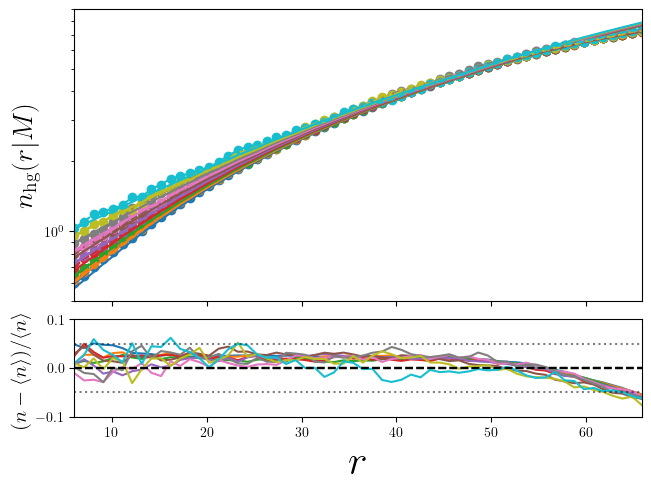

In [ ]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

n_gal = 0.014

for k in range(len(Mvirs2)):
    rho = n_gal*(1+cf_inf(r_cens, Mvirs2[k], cf_pars)) 
    interp = dens_interp(np.log10(Mvirs2[k]), r_cens).squeeze()
    ax[0].scatter(r_cens, r_cens**(3/2)*rho_RM[k], label=r'MDPL2')
    ax[0].plot(r_cens, r_cens**(3/2)*rho, c=f'C{k}',label=r'MAP Model')
    ax[0].plot(r_cens, r_cens**(3/2)*interp, ls='--', c=f'C{k}', label=r'interp')

    ax[1].plot(r_cens, (rho_RM[k] - rho)/rho, c=f'C{k}')
    ax[1].plot(r_cens, (rho_RM[k] - interp)/interp, c=f'C{k}', ls='--')

ax[0].set_yscale('log')

ax[1].axhline(0, c='k', ls='--') 
ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 

ax[1].set_ylim((-0.1, 0.1))

ax[0].set_ylabel(r'$n_{\rm hg}(r|M)$', fontsize=20)
ax[1].set_ylabel(r'$(n - \langle n \rangle )/\langle n \rangle$', fontsize=15)
ax[1].set_xlabel(r'$r$', fontsize=30)

ax[0].margins(x=0)
ax[1].margins(x=0)

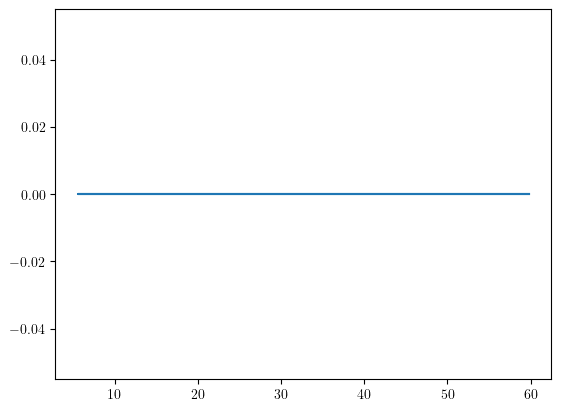

In [194]:
r_test = np.sqrt(R_cens[0]**2 + rlos_cens_dual**2)

interp = dens_interp(np.log10(Mvirs2[k]), r_test, grid=False).squeeze()
interp2 = np.array([dens_interp(np.log10(Mvirs2[k]), r).squeeze() for r in r_test])

plt.plot(r_test, (interp-interp2)/interp2)
# plt.plot(r_cens, interp2)